# P-Wave Rotation Analysis & Receiver Functions


## Background — Body Waves and Receiver Functions

### 0.1  P and S waves

Earthquakes radiate two kinds of **body waves** that travel through the Earth's interior:

| | **P wave** (Primary) | **S wave** (Secondary / Shear) |
|---|---|---|
| **Particle motion** | Parallel to the propagation direction (compressional, push–pull) | Perpendicular to propagation (shear, side-to-side) |
| **Medium** | Travels through solids, liquids, and gases | Travels only through solids (no shear strength in fluids) |
| **Speed** | Fastest body wave; in the crust $V_P \approx 6$–7 km/s | Slower; $V_S \approx V_P / \sqrt{3} \approx 3.5$–4 km/s |
| **Arrival order** | First to arrive at the station | Arrives later — the S–P delay grows with distance |
| **Polarisation on a 3-comp seismometer** | Energy in the **vertical–radial** plane (sagittal plane) | **SV** in sagittal plane; **SH** purely transverse |

Because of these polarisation rules, a properly oriented three-component seismometer can be **rotated** to separate P, SV, and SH energy onto orthogonal channels — this is the foundation of every analysis in this notebook.

#### Mode conversions at interfaces

When a P wave hits a velocity contrast at an angle (e.g. the Moho), part of its energy **converts** to an SV wave, and vice versa.  The most useful conversion for receiver-function analysis is:

$$P \;\xrightarrow{\text{interface}}\; P_s$$

where the converted **Ps** phase travels the rest of the way up as an S wave.  Because S is slower than P, Ps arrives **after** the direct P by an amount that depends on the depth of the interface and the crustal $V_P, V_S$.

---

### 0.2  What is a Receiver Function — and why do we care?

A **receiver function (RF)** is a time series that isolates the **near-receiver Earth response** to an incoming teleseismic P wave by removing the source, mantle path, and instrument effects.  Conceptually:

$$\text{RF}(t) \;\approx\; \text{(local crustal response below the station)}$$

#### The core idea

The vertical-component seismogram $Z(t)$ is dominated by the **direct P wave** plus its source–mantle wavelet $S(t)$.  The radial (or Q) component contains the same wavelet **convolved with the local P-to-S converted phases** generated at sub-station velocity contrasts (Moho, sediment base, intra-crustal layers):

$$Z(t) \;=\; S(t) * I_Z(t), \qquad R(t) \;=\; S(t) * I_R(t)$$

If we **deconvolve** $Z$ from $R$ (or $Q$), the unknown source wavelet cancels and we are left with the local impulse response:

$$\text{RF}(t) \;=\; \mathcal{F}^{-1}\!\left[\frac{R(f)}{Z(f)}\right] \;\approx\; \frac{I_R(t)}{I_Z(t)}$$

The result is a short time series with a **direct-P pulse at $t=0$** followed by **positive pulses for each P-to-S (Ps) conversion** beneath the station.

#### Why we care

| Application | What the RF tells us |
|---|---|
| **Moho depth** | The first large positive pulse (Ps) at $\sim$3–8 s gives crustal thickness via $H = t_{Ps} / (\sqrt{V_s^{-2}-p^2} - \sqrt{V_p^{-2}-p^2})$ |
| **Vp/Vs ratio** | Combining direct Ps with crustal multiples (PpPs, PpSs+PsPs) constrains $V_p/V_s$ — diagnostic of composition (felsic vs. mafic, partial melt, fluids) |
| **Sediment thickness** | Sharp early arrivals (<2 s) reveal sediment basins and their resonance structure |
| **Mantle discontinuities** | Stacking many RFs reveals the 410- and 660-km discontinuities, mantle wedge anisotropy, slabs |
| **Tectonic imaging** | Common-conversion-point (CCP) stacking of arrays maps subduction interfaces, Moho topography, and crustal layering laterally |

#### Why rotation matters here

The deconvolution **only works cleanly** if the denominator ($Z$ or $L$) carries the P energy and the numerator ($R$ or $Q$) carries the converted SV energy.  A poor rotation leaks P energy into the numerator (creating spurious pulses near $t=0$) and leaks SV energy into the denominator (suppressing real conversions).  This notebook quantifies how much rotation choice — back-azimuth alone, vs. data-driven incidence-angle estimates — affects RF quality on the New Zealand array.

## New Zealand Array — Tohoku Mw9.0

Compares **five rotation strategies** for aligning three-component seismograms with the P-wave ray frame, then evaluates how each rotation affects **receiver function (RF) quality**.

| # | Rotation | Basis | Estimates |
|---|----------|-------|-----------|
| 1 | **Z / R / T** | Theoretical back-azimuth from metadata | — (metadata only) |
| 2 | **PCA 2-D** (Z–R plane) | Dominant eigenvector of Z/R covariance in P window | incidence $i$ |
| 3 | **Grid search** (Z–R plane) | Minimise Q-energy fraction in P window | incidence $i$ |
| 4 | **PCA 3-D** (Z–N–E) | Dominant eigenvector of full ZNE covariance in P window | incidence $i$ **and** back-azimuth $\phi$ + rectilinearity quality flag |
| 5 | **L / Q / T** (TauP) | TauP 1-D incidence angle + metadata back-azimuth | incidence $i$ from IASP91 |

PCA 3-D is the only method that estimates back-azimuth from the data itself, so it is also used to flag stations with poor rectilinearity (sensor-orientation errors, scattering, or low SNR). RFs are obtained by **water-level frequency-domain deconvolution** of Z from the converted component (R, Q_PCA2D, Q_grid, Q_PCA3D, Q_TauP). Stacked RFs and pre-P SNR are compared across all methods.

In [44]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

# ── configuration ─────────────────────────────────────────────────────────────
DATA_FILE = Path("tohoku_nz_array.npz")   # swap for kaikoura_nz_array.npz
WL        = 0.01    # water-level fraction for deconvolution
GAUSS_A   = 2.5     # Gaussian width alpha (Hz); larger = sharper but noisier
P_WIN_S   = -0.2    # P-window start for rotation analysis (s rel. predicted P)
P_WIN_E   =  1.5    # P-window end (short → excludes Ps coda; tightens PCA scatter)

# ── load ──────────────────────────────────────────────────────────────────────
data      = np.load(str(DATA_FILE), allow_pickle=True)
Z         = data["Z"].astype(float)
N_comp    = data["N"].astype(float)
E_comp    = data["E"].astype(float)
R         = data["R"].astype(float)
T         = data["T"].astype(float)
L         = data["L"].astype(float)
Q         = data["Q"].astype(float)
distances = data["distances"].astype(float)   # km
dist_deg  = data["dist_deg"].astype(float)
baz_meta  = data["baz"].astype(float)         # back-azimuth (metadata, degrees)
inc_taup  = data["inc_angle"].astype(float)   # TauP incidence angle (degrees from vertical)
stations  = data["stations"]
times_rel = data["times_rel"].astype(float)   # s relative to predicted P
sr        = float(data["sampling_rate"])
dt        = 1.0 / sr

n_sta, n_samp = Z.shape
i_P = int(round(-times_rel[0] * sr))          # sample index of predicted P arrival (t=0)

# sort by distance (ascending)
order    = np.argsort(distances)
Z        = Z[order];       N_comp = N_comp[order];   E_comp = E_comp[order]
R        = R[order];       T      = T[order]
L        = L[order];       Q      = Q[order]
distances = distances[order];  dist_deg = dist_deg[order]
baz_meta  = baz_meta[order];   inc_taup = inc_taup[order]
stations  = stations[order]

print(f"File     : {DATA_FILE.name}")
print(f"Stations : {n_sta}  |  Samples: {n_samp} @ {sr:.0f} sps  "
      f"({times_rel[0]:.0f} to {times_rel[-1]:.0f} s rel. P)")
print(f"Distance : {distances.min():.0f} – {distances.max():.0f} km")
print(f"i_P      : {i_P}  (times_rel[i_P] = {times_rel[i_P]:.3f} s)")

File     : tohoku_nz_array.npz
Stations : 38  |  Samples: 1250 @ 25 sps  (-5 to 45 s rel. P)
Distance : 8541 – 9479 km
i_P      : 125  (times_rel[i_P] = 0.004 s)


## 1  Data Overview — ZNE / ZRT / LQT Record Sections

Each panel shows normalised wiggle traces offset by epicentral distance. The dashed red line marks the predicted P arrival (t = 0). Positive amplitudes are filled.

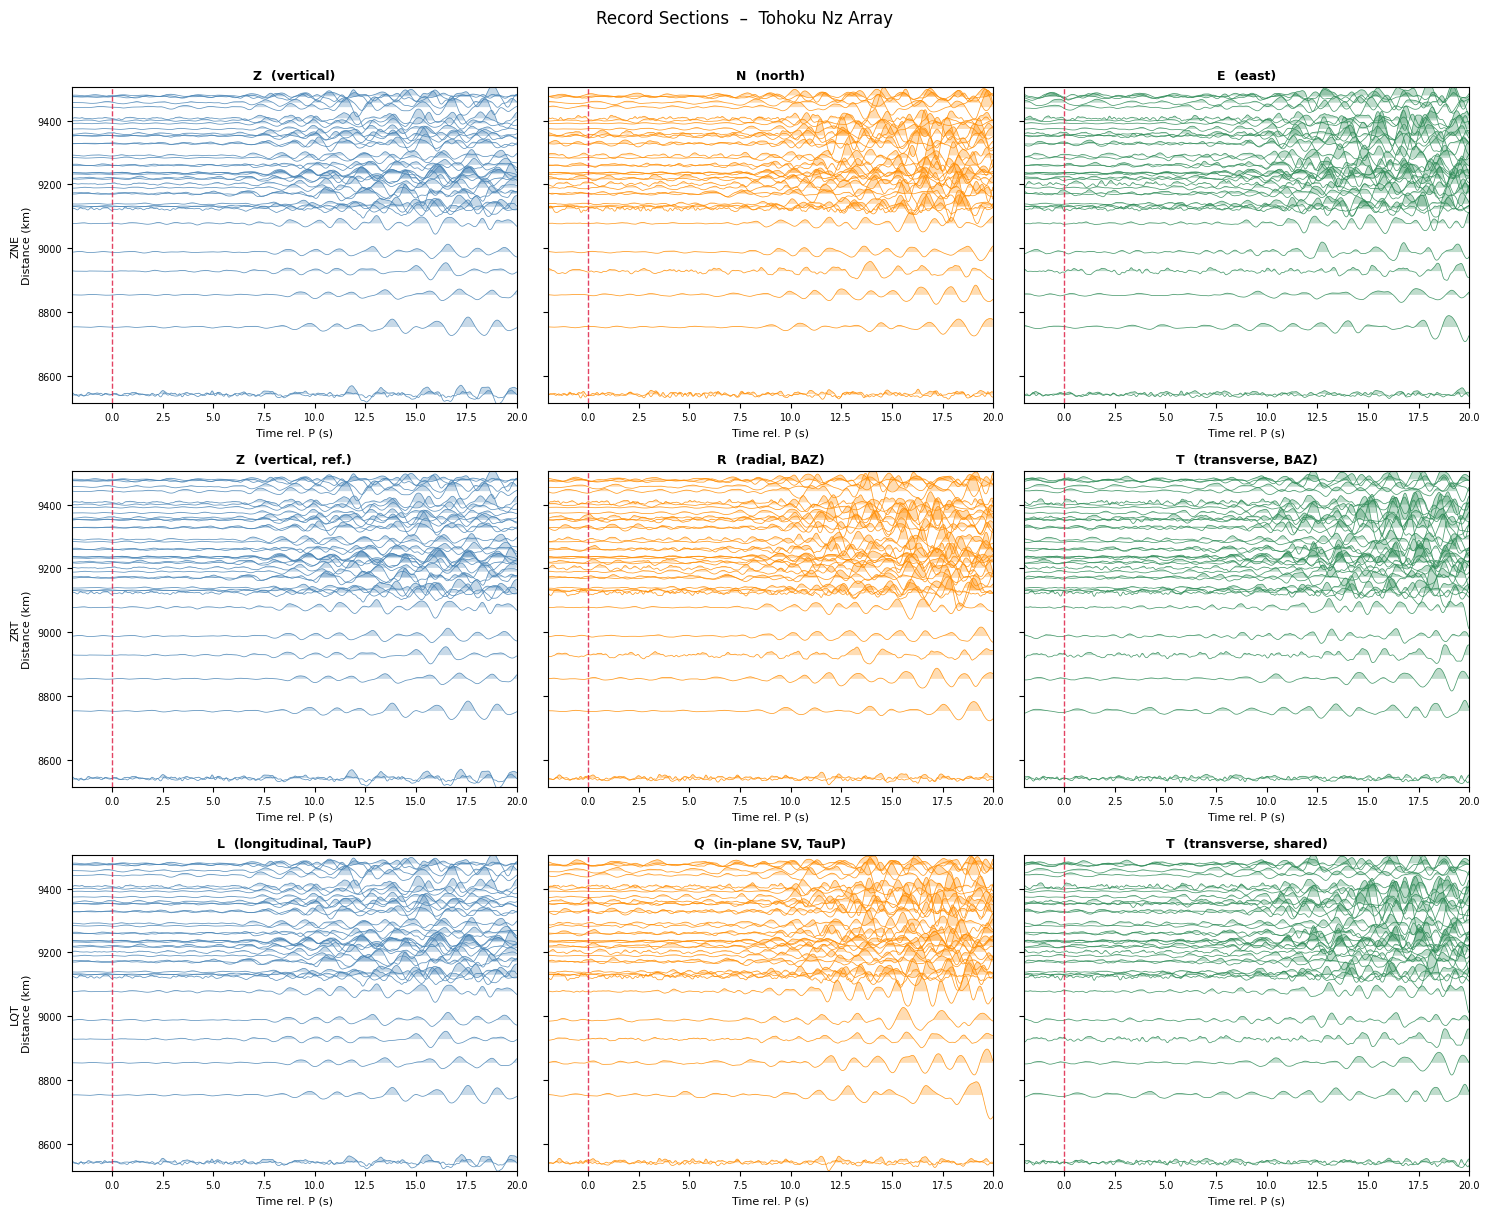

In [45]:
def wiggle_section(ax, data_arr, times, dists, title, color="steelblue",
                   t_lim=(-2, 20), norm_window=(-1, 10)):
    """Plot normalised wiggle traces on ax, offset by distance."""
    mask   = (times >= t_lim[0]) & (times <= t_lim[1])
    n_mask = (times >= norm_window[0]) & (times <= norm_window[1])
    t      = times[mask]
    spacing = np.diff(np.sort(dists)).mean() if len(dists) > 1 else 200.0
    for tr, d in zip(data_arr, dists):
        peak = np.max(np.abs(tr[n_mask])) or 1.0
        seg  = tr[mask] / peak * spacing * 0.45
        ax.plot(t, seg + d, color=color, lw=0.55, alpha=0.85)
        ax.fill_between(t, d, seg + d, where=seg > 0,
                        color=color, alpha=0.30, linewidth=0)
    ax.axvline(0, color="crimson", lw=1.0, ls="--", alpha=0.8)
    ax.set_title(title, fontsize=9, fontweight="bold")
    ax.set_xlabel("Time rel. P (s)", fontsize=8)
    ax.set_xlim(t_lim)
    ax.set_ylim(dists.min() - spacing, dists.max() + spacing)
    ax.tick_params(labelsize=7)

T_LIM = (-2, 20)

fig, axes = plt.subplots(3, 3, figsize=(15, 12), sharey=True)
fig.suptitle(f"Record Sections  –  {DATA_FILE.stem.replace('_', ' ').title()}",
             fontsize=12, y=1.01)

panels = [
    # row 0 — ZNE
    (axes[0, 0], Z,      "steelblue",   "Z  (vertical)"),
    (axes[0, 1], N_comp, "darkorange",  "N  (north)"),
    (axes[0, 2], E_comp, "seagreen",    "E  (east)"),
    # row 1 — ZRT
    (axes[1, 0], Z,      "steelblue",   "Z  (vertical, ref.)"),
    (axes[1, 1], R,      "darkorange",  "R  (radial, BAZ)"),
    (axes[1, 2], T,      "seagreen",    "T  (transverse, BAZ)"),
    # row 2 — LQT
    (axes[2, 0], L,      "steelblue",   "L  (longitudinal, TauP)"),
    (axes[2, 1], Q,      "darkorange",  "Q  (in-plane SV, TauP)"),
    (axes[2, 2], T,      "seagreen",    "T  (transverse, shared)"),
]

for ax, arr, col, lbl in panels:
    wiggle_section(ax, arr, times_rel, distances, lbl, color=col, t_lim=T_LIM)

# Left y-labels per row
for row, label in enumerate(["ZNE", "ZRT", "LQT"]):
    axes[row, 0].set_ylabel(f"{label}\nDistance (km)", fontsize=8)

plt.tight_layout()
plt.show()

## 2  Finding the Optimal Rotation

---

### 2.1  Teleseismic P-wave dynamics

A teleseismic P wave (epicentral distance $\Delta \gtrsim 30°$) has spent most of its travel time deep inside the mantle, where it is a **compressional body wave** propagating as a nearly plane wave by the time it reaches the receiver array.  Several physical facts govern how it looks on a three-component seismometer:

**Ray geometry and incidence angle.**  
As the P wave rises through the crust it refracts according to Snell's law.  The surface incidence angle $i$ (measured from vertical) satisfies

$$\sin i = p \cdot V_P^{\text{surface}}$$

where $p$ (s/km) is the **ray parameter**, which is conserved along the entire ray path and uniquely determined by the epicentral distance $\Delta$.  For teleseismic P at 30–90°, $p \approx 0.04$–$0.08$ s/km, giving $i \approx 10°$–$25°$ for typical crustal $V_P \approx 6$ km/s.  This means the wave arrives **steeply** — most energy is on the vertical component, with a smaller radial-component projection proportional to $\sin i$.

**Particle motion.**  
A pure P wave produces **rectilinear polarisation** strictly in the vertical–radial (sagittal) plane.  On an ideal, flat-layered, isotropic Earth with no noise the transverse (T) component should be identically zero for P.  Any T-component energy in the P coda indicates:
- **Anisotropy** (azimuthal or dipping layers) — splits P into quasi-P and quasi-SV/SH
- **Scattering** (crustal heterogeneity, topography)
- **Misalignment** of the horizontal sensors (orientation error)
- **Noise** (wind, ocean, cultural)

**Slowness and moveout.**  
The horizontal slowness $p$ produces a **moveout** across an array: the P arrival sweeps from the near-side to the far-side stations at a phase velocity $c = 1/p$.  This is used in array beamforming and is why record sections ordered by distance reveal clear linear moveout trends.

---

### 2.2  The standard back-azimuth rotation (ZNE → ZRT)

The most common first step is to project the horizontal components onto the **great-circle path** between source and receiver:

$$\begin{pmatrix} R \\ T \end{pmatrix} = \begin{pmatrix} \cos\phi & \sin\phi \\ -\sin\phi & \cos\phi \end{pmatrix} \begin{pmatrix} N \\ E \end{pmatrix}, \qquad \phi = \text{back-azimuth}$$

where the back-azimuth $\phi$ points from the station back toward the earthquake epicentre.

**What this assumes:**
| Assumption | Consequence if violated |
|---|---|
| Sensors are correctly oriented (N pointing geographic north) | R/T contamination; both components carry unwanted energy |
| Source lies along a single great-circle from the array | Valid for a distant point source; breaks down for finite-fault radiation pattern at close range |
| Earth is laterally homogeneous along the path | Refraction or scattering off off-path heterogeneity rotates the apparent back-azimuth |
| P-wave coda is dominated by in-plane (P–SV) conversions | Anisotropy or dipping interfaces produce non-zero T that is not P–SV |

After this rotation the R component contains the radially-polarised P arrival and SV-type conversions (Ps, PpPs, …); the T component isolates SH-type energy.  The ZRT frame is **kinematically correct** for the horizontal plane but does **not** address the incidence angle — Z and R still mix P and SV energy.

---

### 2.3  The ray-frame rotation (ZR → LQ) and why it matters for receiver functions

The **L** (Longitudinal) and **Q** (Quasi-SV) components are obtained by a second, in-plane rotation through the incidence angle $i$:

$$\begin{pmatrix} L \\ Q \end{pmatrix} = \begin{pmatrix} \cos i & \sin i \\ -\sin i & \cos i \end{pmatrix} \begin{pmatrix} Z \\ R \end{pmatrix}$$

This aligns L with the P-wave ray direction and Q with the orthogonal SV direction.  The practical benefit for **receiver function (RF) analysis** is:

- The **P-wave first motion** is concentrated on L, so deconvolving L from Q removes the source–path wavelet cleanly.
- The **Ps conversion** (P → S at the Moho or other interfaces) appears as a positive pulse on Q at $\sim$4–8 s after P.
- Using R instead of Q for deconvolution leaves residual P-wave projection on the denominator that can distort the RF amplitude and timing.

**The incidence angle $i$ must be known.**  Three approaches are compared here, each with different assumptions:

| Method | What it measures | Key assumptions | What it reveals |
|---|---|---|---|
| **TauP (1-D model)** | Theoretical $i$ from a global 1-D velocity model (e.g. IASP91) | Earth is spherically symmetric; velocity at receiver site matches the model | Baseline prediction; deviations flag local structure |
| **PCA 2-D** | Data-driven $i$ from dominant eigenvector of ZR covariance in P window | P wave is the only coherent signal in the window; noise is incoherent | Actual polarisation seen at that station — absorbs local $V_P$ variation and shallow dip |
| **Grid search** | Data-driven $i$ minimising $E_Q/(E_L+E_Q)$ in P window | P energy should project onto L; Q should be quiet during direct-P | Same physical information as PCA 2-D but more directly tied to the deconvolution objective |
| **PCA 3-D** | Both $i$ and back-azimuth simultaneously from ZNE covariance | P polarisation is rectilinear in 3-D; requires no prior knowledge of source direction | Flags sensor orientation errors or apparent back-azimuth shifts caused by off-path scattering |

**What deviations from TauP tell us:**  
A systematic offset $\Delta i = i_{\text{data}} - i_{\text{TauP}}$ implies the actual near-surface $V_P$ differs from the model — a positive $\Delta i$ (shallower apparent incidence) suggests faster-than-predicted shallow crust; a negative $\Delta i$ suggests slower crust or significant sedimentary cover.  Station-to-station scatter in $\Delta i$ across the New Zealand array reflects genuine lateral heterogeneity in crustal velocity, consistent with the varied tectonic setting (subduction wedge, volcanic arc, cratonic South Island).

---

### 2.4  Rotation matrix for ZR→LQ

In [46]:
# ── rotation helpers ──────────────────────────────────────────────────────────

def rotate_zr_lq(Z_tr, R_tr, inc_deg):
    """Rotate Z/R traces to L/Q using incidence angle inc_deg (degrees from vertical)."""
    i = np.radians(inc_deg)
    L =  Z_tr * np.cos(i) + R_tr * np.sin(i)
    Q = -Z_tr * np.sin(i) + R_tr * np.cos(i)
    return L, Q


def pca_2d_inc(Z_win, R_win):
    """
    2-D PCA on [Z, R] particle motion.
    Returns optimal incidence angle (degrees from vertical).
    """
    X          = np.vstack([Z_win, R_win])
    C          = X @ X.T
    eigvals, eigvecs = np.linalg.eigh(C)
    pc1        = eigvecs[:, -1]
    if pc1[0] < 0:
        pc1 = -pc1
    inc = np.degrees(np.arctan2(abs(pc1[1]), abs(pc1[0])))
    return float(np.clip(inc, 0.0, 90.0))


def pca_3d_angles(Z_win, N_win, E_win):
    """
    3-D PCA on [Z, N, E] particle motion.
    Returns (inc_deg, baz_deg, rect) of the dominant eigenvector.

    inc_deg : incidence angle from vertical (0° = vertical, 90° = horizontal)
    baz_deg : back-azimuth (degrees from north, 0–360°)
    rect    : rectilinearity in [0, 1].  1 = perfectly linear particle motion
              (clean P wave); 0 = isotropic (pure noise).  Defined as
              rect = 1 - (λ2 + λ3) / (2 λ1)   where λ1 ≥ λ2 ≥ λ3.

    Convention: pc1[0] (vertical) is forced positive (upgoing ray).  The
    horizontal projection then points along propagation direction, so
    back-azimuth is the opposite direction (+180°).
    """
    X = np.vstack([Z_win, N_win, E_win])
    C = X @ X.T
    eigvals, eigvecs = np.linalg.eigh(C)   # ascending → λ3, λ2, λ1
    lam3, lam2, lam1 = eigvals
    pc1 = eigvecs[:, -1]
    if pc1[0] < 0:
        pc1 = -pc1
    horiz   = np.hypot(pc1[1], pc1[2])
    inc_deg = float(np.degrees(np.arctan2(horiz, pc1[0])))
    baz_deg = float((np.degrees(np.arctan2(pc1[2], pc1[1])) + 180.0) % 360)
    rect    = float(1.0 - (lam2 + lam3) / (2.0 * lam1 + 1e-30))
    rect    = max(0.0, min(1.0, rect))
    return np.clip(inc_deg, 0.0, 90.0), baz_deg, rect


def grid_search_inc(Z_win, R_win, theta_arr=None):
    """
    Grid search for the incidence angle that minimises Q-energy fraction in the P window.
    Returns (optimal_theta_deg, cost_array).
    """
    if theta_arr is None:
        theta_arr = np.arange(0.0, 90.5, 0.5)
    costs = np.empty(len(theta_arr))
    for k, th in enumerate(theta_arr):
        L, Q     = rotate_zr_lq(Z_win, R_win, th)
        e_L, e_Q = np.dot(L, L), np.dot(Q, Q)
        costs[k] = e_Q / (e_L + e_Q + 1e-15)
    opt_idx = int(np.argmin(costs))
    return float(theta_arr[opt_idx]), costs


THETA_ARR = np.arange(0.0, 90.5, 0.5)

print("Rotation helper functions defined.")

Rotation helper functions defined.


In [47]:
# ── per-station rotation analysis ────────────────────────────────────────────
p_win = (times_rel >= P_WIN_S) & (times_rel <= P_WIN_E)

inc_pca2d   = np.empty(n_sta)
inc_grid    = np.empty(n_sta)
inc_pca3d   = np.empty(n_sta)
baz_pca3d   = np.empty(n_sta)
rect_pca3d  = np.empty(n_sta)   # 3-D PCA rectilinearity (quality flag)

Q_pca2d  = np.empty_like(Z)
Q_grid   = np.empty_like(Z)
Q_pca3d  = np.empty_like(Z)

MAX_DEV    = 20.0   # degrees — supplementary-angle correction tolerance
RECT_GOOD  = 0.85   # rectilinearity threshold for "good" station

def snap_to_reference(angle, reference, max_dev=MAX_DEV):
    """Correct for eigenvector quadrant ambiguity (try 90° - angle if far from ref)."""
    angle = float(np.clip(angle, 0.0, 90.0))
    if abs(angle - reference) <= max_dev:
        return angle
    supplement = float(np.clip(90.0 - angle, 0.0, 90.0))
    if abs(supplement - reference) < abs(angle - reference):
        return supplement
    return angle

for i in range(n_sta):
    Z_w, R_w   = Z[i, p_win], R[i, p_win]
    N_w, E_w   = N_comp[i, p_win], E_comp[i, p_win]
    ref_i      = inc_taup[i]

    raw_pca2d    = pca_2d_inc(Z_w, R_w)
    inc_pca2d[i] = snap_to_reference(raw_pca2d, ref_i)

    raw_grid, _  = grid_search_inc(Z_w, R_w, THETA_ARR)
    inc_grid[i]  = snap_to_reference(raw_grid, ref_i)

    raw_pca3d, baz_pca3d[i], rect_pca3d[i] = pca_3d_angles(Z_w, N_w, E_w)
    inc_pca3d[i] = snap_to_reference(raw_pca3d, ref_i)

    _, Q_pca2d[i]  = rotate_zr_lq(Z[i], R[i], inc_pca2d[i])
    _, Q_grid[i]   = rotate_zr_lq(Z[i], R[i], inc_grid[i])

    baz_i  = np.radians(baz_pca3d[i])
    R_pca  = -N_comp[i] * np.sin(baz_i) + E_comp[i] * np.cos(baz_i)
    _, Q_pca3d[i] = rotate_zr_lq(Z[i], R[i], inc_pca3d[i])

# ── summary table with quality flag ──────────────────────────────────────────
print(f"P-window: ({P_WIN_S}, {P_WIN_E}) s   |   "
      f"rectilinearity threshold: {RECT_GOOD}")
print()
print(f"{'Station':<12}  {'dist(km)':>8}  {'TauP i':>6}  {'PCA2D i':>7}  "
      f"{'Grid i':>6}  {'PCA3D i':>7}  {'BAZ_meta':>8}  {'BAZ_pca3d':>9}  "
      f"{'rect':>5}  {'qual':>4}")
print("-" * 100)
for j in range(n_sta):
    qual = "good" if rect_pca3d[j] >= RECT_GOOD else "POOR"
    print(f"{stations[j]:<12}  {distances[j]:8.0f}  {inc_taup[j]:6.1f}  "
          f"{inc_pca2d[j]:7.1f}  {inc_grid[j]:6.1f}  {inc_pca3d[j]:7.1f}  "
          f"{baz_meta[j]:8.1f}  {baz_pca3d[j]:9.1f}  "
          f"{rect_pca3d[j]:5.2f}  {qual:>4}")

n_good = int((rect_pca3d >= RECT_GOOD).sum())
print(f"\n{n_good}/{n_sta} stations pass rectilinearity > {RECT_GOOD}")

P-window: (-0.2, 1.5) s   |   rectilinearity threshold: 0.85

Station       dist(km)  TauP i  PCA2D i  Grid i  PCA3D i  BAZ_meta  BAZ_pca3d   rect  qual
----------------------------------------------------------------------------------------------------
NZ.RIZ            8541    17.0     12.4    12.5     12.5     328.9      312.0   0.67  POOR
NZ.GLKZ           8543    17.0     15.1     0.0      7.9     328.9      102.2   0.88  good
NZ.OUZ            8753    16.6     26.5    26.5     42.0     335.4       31.2   0.87  good
NZ.WCZ            8854    16.4     41.5    41.5     44.2     334.9      311.1   0.89  good
NZ.GRZ            8928    16.2      7.1     7.0      5.8     334.1      292.4   0.89  good
NZ.KUZ            8988    16.1     14.6    14.5     14.7     334.0      330.0   0.96  good
NZ.TOZ            9078    15.9     17.1    17.0     17.1     334.2      331.6   0.97  good
NZ.WIZ            9124    15.8     24.5    24.5     23.8     333.0      314.0   0.71  POOR
NZ.OPRZ           

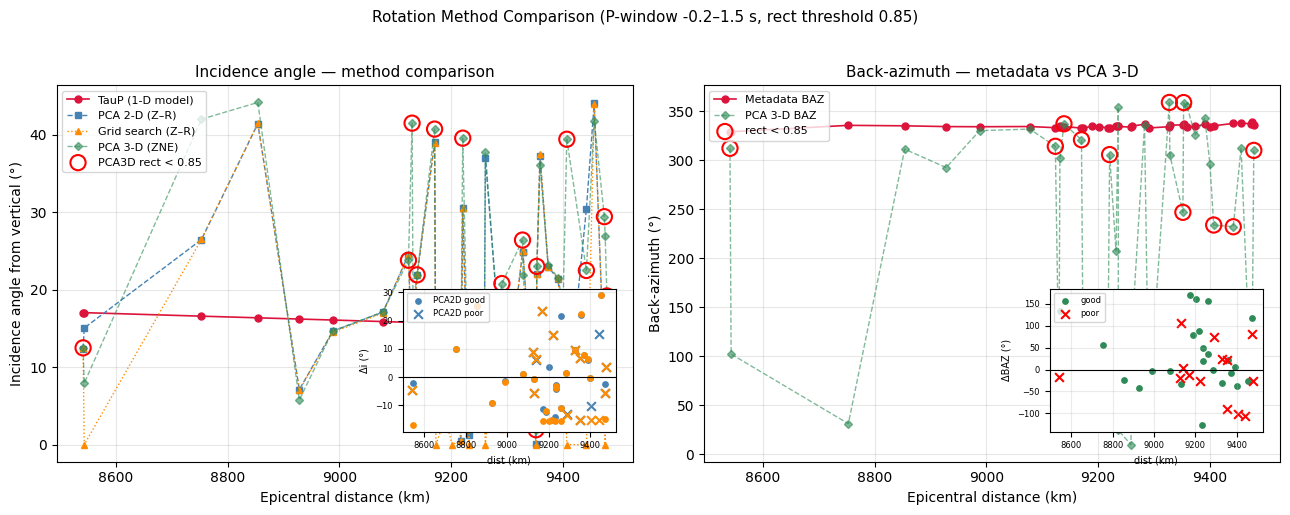

Mean absolute deviation from TauP / metadata (deg):
  method              all   good only
  ------------------------------------
  PCA2D − TauP       9.65        9.33
  Grid  − TauP      10.84       11.00
  PCA3D − TauP      11.05        9.94
  ΔBAZ PCA3D        56.30       59.73


In [48]:
# ── rotation comparison plots (quality-aware) ────────────────────────────────
good = rect_pca3d >= RECT_GOOD
poor = ~good

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Panel A: incidence angle comparison ──────────────────────────────────────
ax = axes[0]
ax.plot(distances, inc_taup,  "o-",  color="crimson",   lw=1.2, ms=5, label="TauP (1-D model)")
ax.plot(distances, inc_pca2d, "s--", color="steelblue", lw=1.0, ms=4, label="PCA 2-D (Z–R)")
ax.plot(distances, inc_grid,  "^:",  color="darkorange", lw=1.0, ms=4, label="Grid search (Z–R)")
ax.plot(distances, inc_pca3d, "D--", color="seagreen",   lw=1.0, ms=4, label="PCA 3-D (ZNE)", alpha=0.6)
# overlay markers showing quality of PCA-3D fit
ax.scatter(distances[poor], inc_pca3d[poor], s=120, facecolors="none",
           edgecolors="red", linewidths=1.5, label=f"PCA3D rect < {RECT_GOOD}", zorder=4)
ax.set_xlabel("Epicentral distance (km)", fontsize=10)
ax.set_ylabel("Incidence angle from vertical (°)", fontsize=10)
ax.set_title("Incidence angle — method comparison", fontsize=11)
ax.legend(fontsize=8, loc="upper left")
ax.grid(alpha=0.3)

# residual inset (good vs poor stations)
ax_in = ax.inset_axes([0.60, 0.08, 0.37, 0.38])
ax_in.axhline(0, color="k", lw=0.8)
ax_in.scatter(distances[good], (inc_pca2d - inc_taup)[good],
              c="steelblue", s=15, label="PCA2D good")
ax_in.scatter(distances[poor], (inc_pca2d - inc_taup)[poor],
              c="steelblue", s=40, marker="x", label="PCA2D poor")
ax_in.scatter(distances[good], (inc_grid - inc_taup)[good],
              c="darkorange", s=15)
ax_in.scatter(distances[poor], (inc_grid - inc_taup)[poor],
              c="darkorange", s=40, marker="x")
ax_in.set_ylabel("Δi (°)", fontsize=7)
ax_in.set_xlabel("dist (km)", fontsize=7)
ax_in.tick_params(labelsize=6)
ax_in.legend(fontsize=6, loc="upper left")
ax_in.grid(alpha=0.25)

# ── Panel B: back-azimuth comparison ─────────────────────────────────────────
ax = axes[1]
ax.plot(distances, baz_meta,  "o-",  color="crimson",  lw=1.2, ms=5, label="Metadata BAZ")
ax.plot(distances, baz_pca3d, "D--", color="seagreen", lw=1.0, ms=4, label="PCA 3-D BAZ", alpha=0.6)
ax.scatter(distances[poor], baz_pca3d[poor], s=120, facecolors="none",
           edgecolors="red", linewidths=1.5, label=f"rect < {RECT_GOOD}", zorder=4)

delta_baz = ((baz_pca3d - baz_meta + 180) % 360) - 180
ax_in2 = ax.inset_axes([0.60, 0.08, 0.37, 0.38])
ax_in2.axhline(0, color="k", lw=0.8)
ax_in2.scatter(distances[good], delta_baz[good], c="seagreen", s=15, label="good")
ax_in2.scatter(distances[poor], delta_baz[poor], c="red",      s=40, marker="x", label="poor")
ax_in2.set_ylabel("ΔBAZ (°)", fontsize=7)
ax_in2.set_xlabel("dist (km)", fontsize=7)
ax_in2.tick_params(labelsize=6)
ax_in2.legend(fontsize=6, loc="upper left")
ax_in2.grid(alpha=0.25)

ax.set_xlabel("Epicentral distance (km)", fontsize=10)
ax.set_ylabel("Back-azimuth (°)", fontsize=10)
ax.set_title("Back-azimuth — metadata vs PCA 3-D", fontsize=11)
ax.legend(fontsize=8, loc="upper left")
ax.grid(alpha=0.3)

plt.suptitle(f"Rotation Method Comparison "
             f"(P-window {P_WIN_S}–{P_WIN_E} s, rect threshold {RECT_GOOD})",
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

# ── stats: all stations vs good-only ─────────────────────────────────────────
print("Mean absolute deviation from TauP / metadata (deg):")
print(f"  {'method':<14}  {'all':>7}  {'good only':>10}")
print("  " + "-" * 36)
for label, vals in [
    ("PCA2D − TauP",  inc_pca2d - inc_taup),
    ("Grid  − TauP",  inc_grid  - inc_taup),
    ("PCA3D − TauP",  inc_pca3d - inc_taup),
    ("ΔBAZ PCA3D",    delta_baz),
]:
    all_mean  = np.abs(vals).mean()
    good_mean = np.abs(vals[good]).mean() if good.any() else float("nan")
    print(f"  {label:<14}  {all_mean:7.2f}  {good_mean:10.2f}")

## 3  Receiver Functions via Deconvolution

### Water-level frequency-domain deconvolution (Langston 1979)

In the frequency domain, the horizontal component $H(f)$ is approximately a receiver function $\text{RF}(f)$ convolved with the source term $Z(f)$:

$$H(f) = \text{RF}(f) \cdot Z(f)$$

Solving for $\text{RF}$:

$$\text{RF}(f) = \frac{H(f) \cdot Z^*(f)}{|Z(f)|^2 + \phi} \cdot G(f)$$

where $\phi = \lambda \cdot \max|Z(f)|^2$ is the water level (prevents division by zero near spectral nulls) and $G(f) = e^{-(\pi f / \alpha)^2}$ is a Gaussian low-pass filter.

After IFFT, the RF is **rolled by `i_P` samples** so the direct-P pulse aligns with $t = 0$ in `times_rel`.

**Four numerators are compared — all with Z as denominator:**

| Label | Numerator | Incidence angle used |
|-------|-----------|----------------------|
| `RF_R` | R (BAZ rotation) | metadata baz only |
| `RF_Q_pca2d` | Q rotated via PCA 2-D | PCA-estimated, per station |
| `RF_Q_grid` | Q rotated via grid search | energy-optimal, per station |
| `RF_Q_taup` | Q from TauP LQT (precomputed) | TauP model, per station |

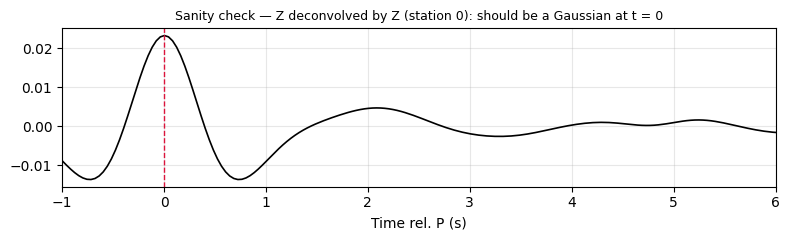

RF shapes: {'R  (BAZ)': (38, 1250), 'Q  (PCA 2D)': (38, 1250), 'Q  (Grid)': (38, 1250), 'Q  (TauP)': (38, 1250)}


In [49]:
# ── water-level deconvolution ─────────────────────────────────────────────────

def water_level_decon(num, den, dt, wl=0.01, gauss_a=2.5):
    """
    Spectral water-level deconvolution (Langston 1979).

    Parameters
    ----------
    num     : numerator trace (converted component, e.g. R or Q)
    den     : denominator trace (source estimate, i.e. Z)
    dt      : sample interval (s)
    wl      : water-level fraction of peak denominator power  [0.01 = 1 %]
    gauss_a : Gaussian width alpha (Hz); controls high-frequency roll-off

    Returns
    -------
    rf : receiver function, same length as input.
         The direct-P pulse is located at sample index 0.
         Roll by i_P to place the pulse at t = 0 in times_rel.
    """
    n     = len(num)
    F_num = np.fft.rfft(num, n=n)
    F_den = np.fft.rfft(den, n=n)
    power = np.abs(F_den) ** 2
    phi   = wl * power.max()
    F_rf  = F_num * np.conj(F_den) / (power + phi)
    freq  = np.fft.rfftfreq(n, d=dt)
    F_rf *= np.exp(-(np.pi * freq / gauss_a) ** 2)    # Gaussian taper
    return np.fft.irfft(F_rf, n=n)


def compute_all_rfs(numerators_dict, Z_arr, dt, i_P, wl=WL, gauss_a=GAUSS_A):
    """
    Compute RFs for every numerator in numerators_dict.

    Returns {label: (n_sta, n_samp) array}  with P aligned at sample i_P.
    """
    n_sta, n_samp = Z_arr.shape
    out = {}
    for label, num_arr in numerators_dict.items():
        rfs = np.empty((n_sta, n_samp))
        for i in range(n_sta):
            raw       = water_level_decon(num_arr[i], Z_arr[i], dt, wl=wl, gauss_a=gauss_a)
            rfs[i]    = np.roll(raw, i_P)   # place P pulse at sample i_P → t = 0
        out[label] = rfs
    return out


# ── compute receiver functions for all four rotation methods ─────────────────
numerators = {
    "R  (BAZ)"    : R,
    "Q  (PCA 2D)" : Q_pca2d,
    "Q  (Grid)"   : Q_grid,
    "Q  (TauP)"   : Q,
}

RF = compute_all_rfs(numerators, Z, dt, i_P, wl=WL, gauss_a=GAUSS_A)

# Verify — deconvolution of Z by itself should give a Gaussian pulse at t=0
RF_self = np.roll(water_level_decon(Z[0], Z[0], dt, wl=WL, gauss_a=GAUSS_A), i_P)

fig, ax = plt.subplots(figsize=(8, 2.5))
ax.plot(times_rel, RF_self, color="k", lw=1.2)
ax.axvline(0, color="crimson", ls="--", lw=1)
ax.set_title("Sanity check — Z deconvolved by Z (station 0): should be a Gaussian at t = 0",
             fontsize=9)
ax.set_xlabel("Time rel. P (s)");  ax.set_xlim(-1, 6)
ax.grid(alpha=0.3)
plt.tight_layout();  plt.show()

print("RF shapes:", {k: v.shape for k, v in RF.items()})

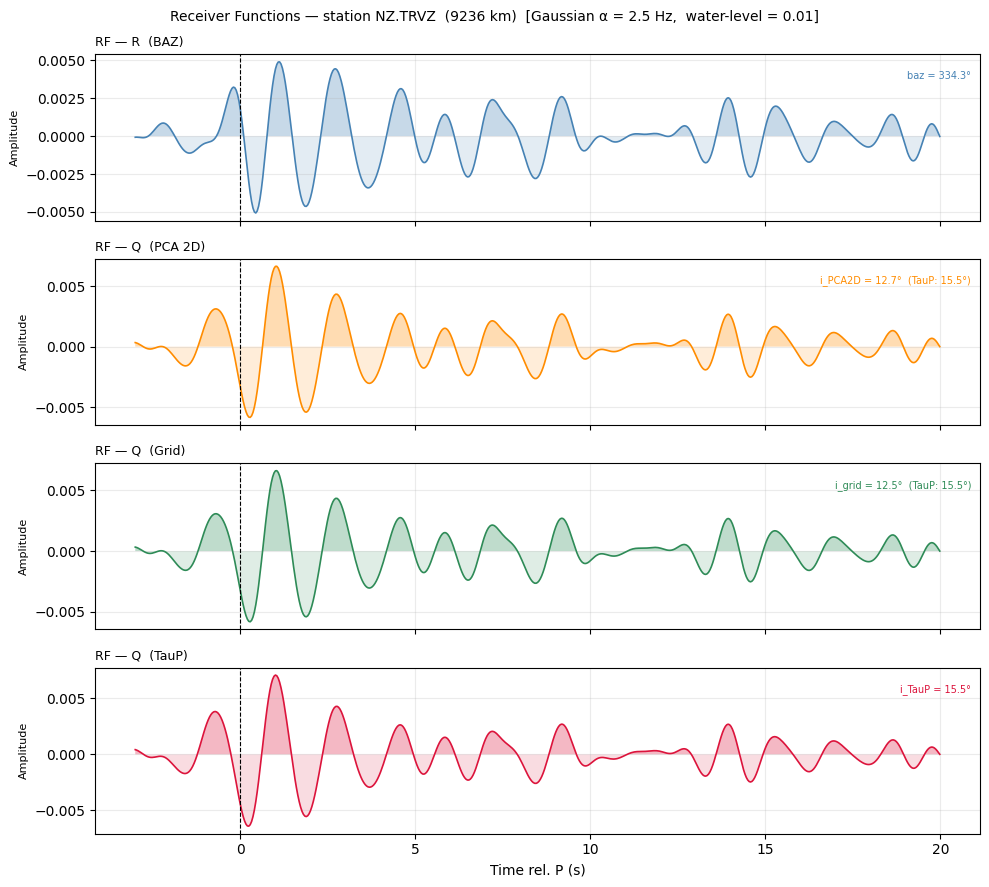

In [50]:
# ── Example station — compare all 4 RFs on one plot ─────────────────────────
STA_IDX = n_sta // 2      # pick a middle-distance station; change as desired
t_plot  = (times_rel >= -3) & (times_rel <= 20)
t_ax    = times_rel[t_plot]

COLORS  = ["steelblue", "darkorange", "seagreen", "crimson"]
LABELS  = list(RF.keys())

fig, axes = plt.subplots(4, 1, figsize=(10, 9), sharex=True)
fig.suptitle(f"Receiver Functions — station {stations[STA_IDX]}  "
             f"({distances[STA_IDX]:.0f} km)  "
             f"[Gaussian α = {GAUSS_A} Hz,  water-level = {WL}]",
             fontsize=10)

for ax, (label, rfs), col in zip(axes, RF.items(), COLORS):
    tr = rfs[STA_IDX, t_plot]
    ax.plot(t_ax, tr, color=col, lw=1.2, label=label)
    ax.fill_between(t_ax, 0, tr, where=tr > 0, color=col, alpha=0.3, linewidth=0)
    ax.fill_between(t_ax, 0, tr, where=tr < 0, color=col, alpha=0.15, linewidth=0)
    ax.axvline(0, color="k", lw=0.8, ls="--")
    ax.set_ylabel("Amplitude", fontsize=8)
    ax.set_title(f"RF — {label}", fontsize=9, loc="left")
    ax.grid(alpha=0.25)
    # Annotate rotation angle used
    if "BAZ" in label:
        note = f"baz = {baz_meta[STA_IDX]:.1f}°"
    elif "PCA 2D" in label:
        note = f"i_PCA2D = {inc_pca2d[STA_IDX]:.1f}°  (TauP: {inc_taup[STA_IDX]:.1f}°)"
    elif "Grid" in label:
        note = f"i_grid = {inc_grid[STA_IDX]:.1f}°  (TauP: {inc_taup[STA_IDX]:.1f}°)"
    else:
        note = f"i_TauP = {inc_taup[STA_IDX]:.1f}°"
    ax.text(0.99, 0.90, note, transform=ax.transAxes, ha="right", va="top",
            fontsize=7, color=col)

axes[-1].set_xlabel("Time rel. P (s)", fontsize=10)
plt.tight_layout()
plt.show()

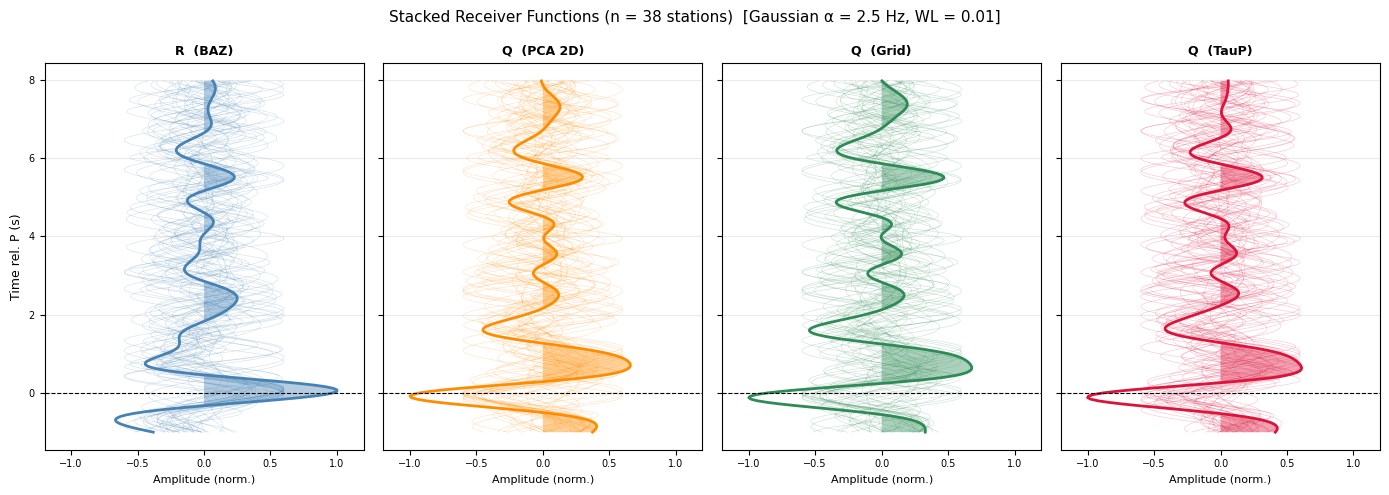

In [51]:
# ── Stacked receiver functions — all methods side by side ────────────────────
# Optional distance normalisation before stacking (avoids near-far bias)

def stack_rfs(rf_arr, normalize_each=True):
    """Stack RFs across stations. Optionally normalise each trace to unit peak."""
    if normalize_each:
        peaks = np.max(np.abs(rf_arr), axis=1, keepdims=True)
        peaks = np.where(peaks == 0, 1, peaks)
        return np.mean(rf_arr / peaks, axis=0)
    return np.mean(rf_arr, axis=0)


t_plot  = (times_rel >= -1) & (times_rel <= 8)
t_ax    = times_rel[t_plot]

fig, axes = plt.subplots(1, 4, figsize=(14, 5), sharey=True)
fig.suptitle(f"Stacked Receiver Functions (n = {n_sta} stations)  "
             f"[Gaussian α = {GAUSS_A} Hz, WL = {WL}]",
             fontsize=11)

for ax, (label, rfs), col in zip(axes, RF.items(), COLORS):
    # Individual traces (light)
    for i in range(n_sta):
        tr_i = rfs[i, t_plot]
        p    = np.max(np.abs(tr_i)) or 1.0
        ax.plot(tr_i / p * 0.6, t_ax, color=col, lw=0.4, alpha=0.25)

    # Mean stack (bold)
    stk = stack_rfs(rfs[:, t_plot])
    ax.plot(stk / (np.max(np.abs(stk)) or 1), t_ax, color=col, lw=2.0)
    ax.fill_betweenx(t_ax, 0, stk / (np.max(np.abs(stk)) or 1),
                     where=stk > 0, color=col, alpha=0.40, linewidth=0)
    ax.axhline(0, color="k", lw=0.8, ls="--")
    ax.set_title(label, fontsize=9, fontweight="bold")
    ax.set_xlabel("Amplitude (norm.)", fontsize=8)
    ax.set_xlim(-1.2, 1.2)
    ax.grid(alpha=0.25, axis="y")
    ax.tick_params(labelsize=7)

axes[0].set_ylabel("Time rel. P (s)", fontsize=9)
plt.tight_layout()
plt.show()

## 4  Signal-to-Noise Analysis

**SNR is computed on each per-station RF trace:**

$$\text{SNR (dB)} = 20 \log_{10} \frac{\text{RMS}(t \in [0,\, 15]\,\text{s})}{\text{RMS}(t \in [-5,\,-0.5]\,\text{s})}$$

- **Signal window** $[0, 15]$ s: direct P pulse + Ps conversion + early multiples  
- **Noise window** $[-5, -0.5]$ s: pre-P arrivals (ambient noise + pre-event)

A higher SNR means the rotation better isolated the converted energy onto the numerator component without amplifying pre-P noise during deconvolution.

In [52]:
# ── SNR computation ───────────────────────────────────────────────────────────
SIG_START, SIG_END    =  0.0, 15.0   # signal window (s rel. P)
NOISE_START, NOISE_END = -5.0, -0.5  # noise window

sig_mask   = (times_rel >= SIG_START)   & (times_rel <= SIG_END)
noise_mask = (times_rel >= NOISE_START) & (times_rel <= NOISE_END)

def snr_db(rf_arr, sig_mask, noise_mask):
    """Return per-station SNR in dB."""
    rms_sig   = np.sqrt(np.mean(rf_arr[:, sig_mask]   ** 2, axis=1))
    rms_noise = np.sqrt(np.mean(rf_arr[:, noise_mask] ** 2, axis=1))
    with np.errstate(divide="ignore", invalid="ignore"):
        snr = 20.0 * np.log10(rms_sig / np.where(rms_noise == 0, 1e-15, rms_noise))
    return snr

snr = {label: snr_db(rfs, sig_mask, noise_mask) for label, rfs in RF.items()}

# print summary table
print(f"{'Method':<18}  {'Mean SNR':>8}  {'Median SNR':>10}  {'Min SNR':>8}  {'Max SNR':>8}")
print("-" * 58)
for label, vals in snr.items():
    print(f"{label:<18}  {vals.mean():8.2f}  {np.median(vals):10.2f}  "
          f"{vals.min():8.2f}  {vals.max():8.2f}")

Method              Mean SNR  Median SNR   Min SNR   Max SNR
----------------------------------------------------------
R  (BAZ)                4.09        3.36     -2.02     10.48
Q  (PCA 2D)             3.83        4.20     -2.23      9.29
Q  (Grid)               4.05        4.34     -2.24      9.25
Q  (TauP)               5.16        5.35     -2.48      9.42


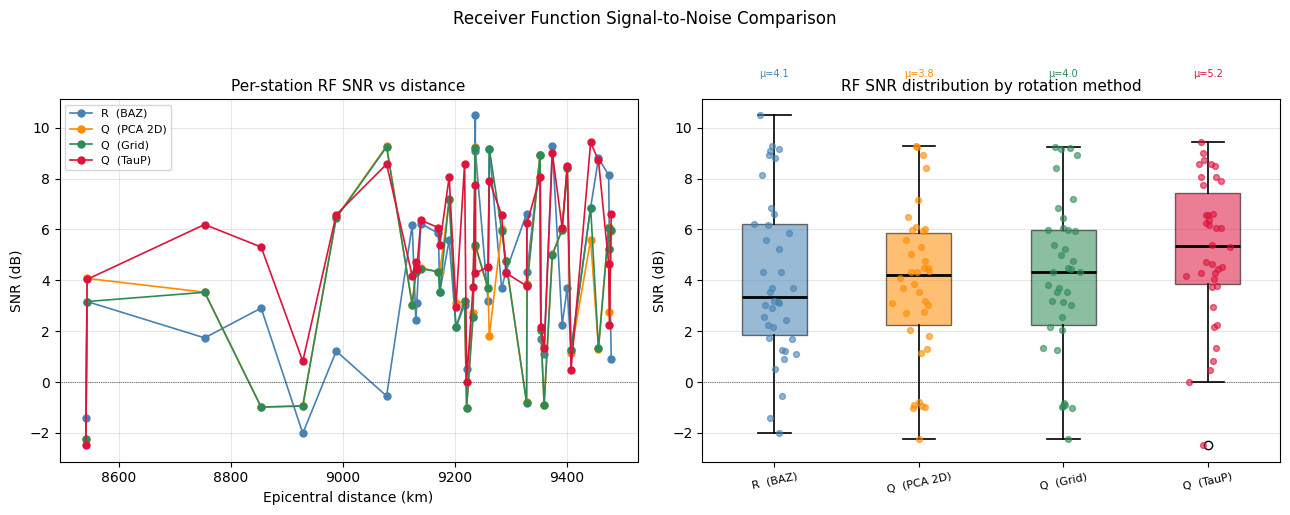

In [53]:
# ── SNR visualisation ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Panel A: per-station SNR vs distance ─────────────────────────────────────
ax = axes[0]
for (label, vals), col in zip(snr.items(), COLORS):
    ax.plot(distances, vals, "o-", color=col, lw=1.2, ms=5, label=label)
ax.set_xlabel("Epicentral distance (km)", fontsize=10)
ax.set_ylabel("SNR (dB)", fontsize=10)
ax.set_title("Per-station RF SNR vs distance", fontsize=11)
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
ax.axhline(0, color="k", lw=0.5, ls=":")

# ── Panel B: boxplot comparison ───────────────────────────────────────────────
ax = axes[1]
snr_data   = [vals for vals in snr.values()]
bp = ax.boxplot(snr_data, patch_artist=True, notch=False,
                medianprops=dict(color="k", lw=2),
                whiskerprops=dict(lw=1.2),
                capprops=dict(lw=1.2))
for patch, col in zip(bp["boxes"], COLORS):
    patch.set_facecolor(col)
    patch.set_alpha(0.55)

# Overlay individual points
for j, (vals, col) in enumerate(zip(snr_data, COLORS), start=1):
    x = np.random.normal(j, 0.07, size=len(vals))
    ax.scatter(x, vals, color=col, alpha=0.6, s=18, zorder=3)

ax.set_xticks(range(1, len(snr) + 1))
ax.set_xticklabels(list(snr.keys()), fontsize=8, rotation=12)
ax.set_ylabel("SNR (dB)", fontsize=10)
ax.set_title("RF SNR distribution by rotation method", fontsize=11)
ax.axhline(0, color="k", lw=0.5, ls=":")
ax.grid(alpha=0.3, axis="y")

# Annotate mean
for j, (label, vals) in enumerate(snr.items(), start=1):
    ax.text(j, np.max(snr_data) + 1.5, f"μ={vals.mean():.1f}",
            ha="center", fontsize=7, color=COLORS[j - 1])

plt.suptitle("Receiver Function Signal-to-Noise Comparison", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## 5  Parameter Sensitivity — Water-level & Gaussian Width

Sweeps water-level $\lambda$ and Gaussian $\alpha$ for each rotation method, reporting mean stacked-RF peak amplitude and mean SNR. Helps choose optimal deconvolution parameters before publishing.

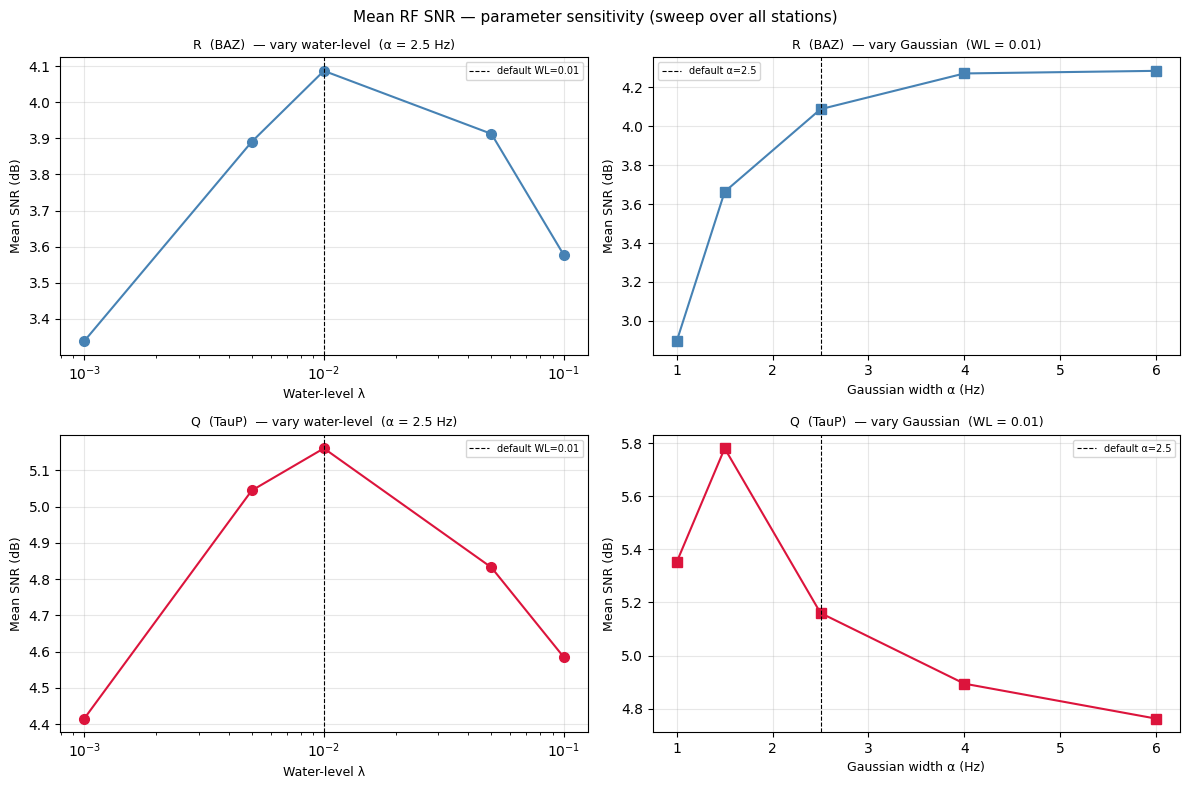

In [54]:
# ── parameter sensitivity sweep ───────────────────────────────────────────────
WL_GRID     = [0.001, 0.005, 0.01, 0.05, 0.10]
GAUSS_GRID  = [1.0, 1.5, 2.5, 4.0, 6.0]

# Focus on two methods for clarity: BAZ R and TauP Q
sweep_methods = {
    "R  (BAZ)"  : R,
    "Q  (TauP)" : Q,
}

fig, axes = plt.subplots(len(sweep_methods), 2,
                         figsize=(12, 4 * len(sweep_methods)), squeeze=False)
fig.suptitle("Mean RF SNR — parameter sensitivity (sweep over all stations)", fontsize=11)

for row, (method_label, num_arr) in enumerate(sweep_methods.items()):
    col_method = COLORS[list(RF.keys()).index(method_label)]

    # ── left panel: vary water-level (fix Gaussian at default) ───────────────
    ax = axes[row, 0]
    snr_wl = []
    for wl in WL_GRID:
        rf_tmp = compute_all_rfs({method_label: num_arr}, Z, dt, i_P,
                                  wl=wl, gauss_a=GAUSS_A)
        snr_tmp = snr_db(rf_tmp[method_label], sig_mask, noise_mask)
        snr_wl.append(snr_tmp.mean())
    ax.semilogx(WL_GRID, snr_wl, "o-", color=col_method, lw=1.5, ms=7)
    ax.axvline(WL, color="k", ls="--", lw=0.8, label=f"default WL={WL}")
    ax.set_xlabel("Water-level λ", fontsize=9)
    ax.set_ylabel("Mean SNR (dB)", fontsize=9)
    ax.set_title(f"{method_label}  — vary water-level  (α = {GAUSS_A} Hz)", fontsize=9)
    ax.legend(fontsize=7);  ax.grid(alpha=0.3)

    # ── right panel: vary Gaussian (fix water-level at default) ──────────────
    ax = axes[row, 1]
    snr_ga = []
    for ga in GAUSS_GRID:
        rf_tmp = compute_all_rfs({method_label: num_arr}, Z, dt, i_P,
                                  wl=WL, gauss_a=ga)
        snr_tmp = snr_db(rf_tmp[method_label], sig_mask, noise_mask)
        snr_ga.append(snr_tmp.mean())
    ax.plot(GAUSS_GRID, snr_ga, "s-", color=col_method, lw=1.5, ms=7)
    ax.axvline(GAUSS_A, color="k", ls="--", lw=0.8, label=f"default α={GAUSS_A}")
    ax.set_xlabel("Gaussian width α (Hz)", fontsize=9)
    ax.set_ylabel("Mean SNR (dB)", fontsize=9)
    ax.set_title(f"{method_label}  — vary Gaussian  (WL = {WL})", fontsize=9)
    ax.legend(fontsize=7);  ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 6  Q-Component Receiver Functions — Record Section by Distance

Wiggle traces sorted by epicentral distance. Each trace is normalised to its own peak amplitude. Positive fills mark P-to-S converted energy. The dashed line marks t = 0 (predicted P).

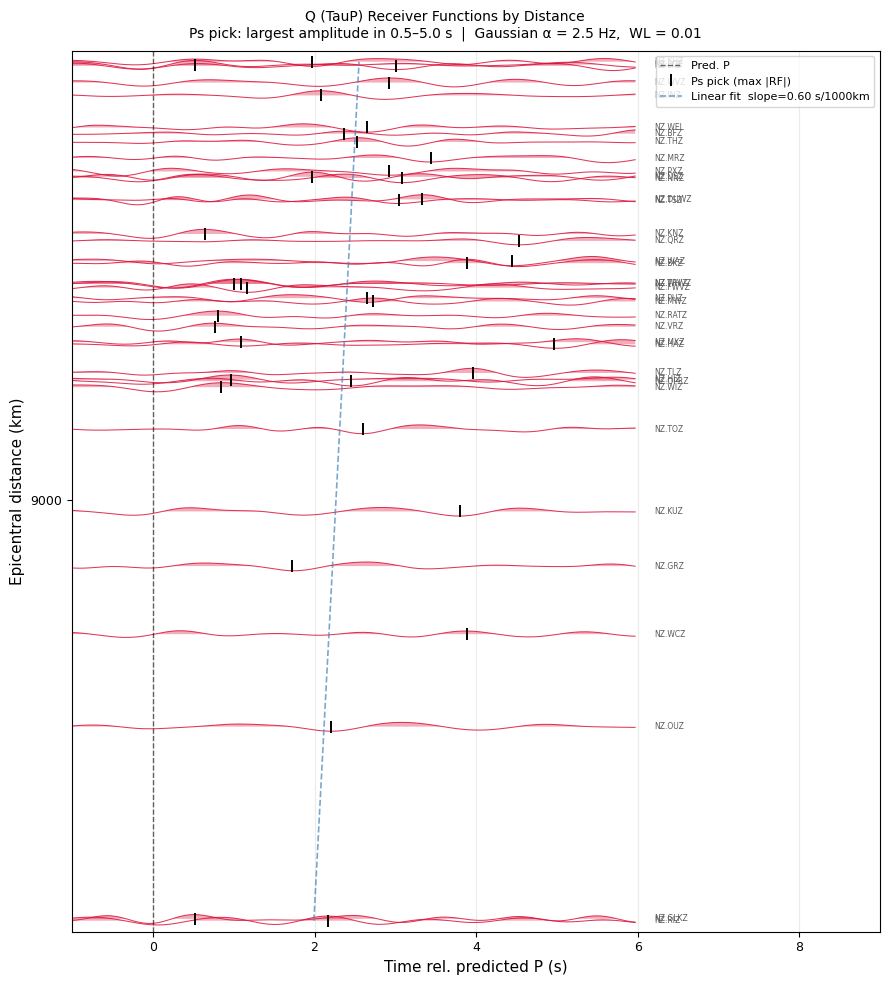


Crustal thickness (Vp = 6.8 km/s,  Vp/Vs = 1.732,  Vs = 3.926 km/s)
Station       dist(km)   Ps (s)   i_TauP   p (s/km)   H (km)
-----------------------------------------------------------------
NZ.RIZ            8541    2.166     17.0    0.04311     19.6
NZ.GLKZ           8543    0.524     17.0    0.04310      4.7
NZ.OUZ            8753    2.206     16.6    0.04199     20.0
NZ.WCZ            8854    3.887     16.4    0.04146     35.3
NZ.GRZ            8928    1.725     16.2    0.04107     15.7
NZ.KUZ            8988    3.807     16.1    0.04076     34.6
NZ.TOZ            9078    2.606     15.9    0.04027     23.7
NZ.WIZ            9124    0.845     15.8    0.04003      7.7
NZ.OPRZ           9130    2.446     15.8    0.03999     22.2
NZ.HIZ            9132    0.965     15.8    0.03998      8.8
NZ.TLZ            9139    3.967     15.8    0.03994     36.1
NZ.HAZ            9170    4.968     15.7    0.03979     45.2
NZ.MXZ            9173    1.085     15.7    0.03977      9.9
NZ.VRZ     

In [55]:
# ── TauP Q RF record section with Ps pick ────────────────────────────────────
RF_TAUP   = RF["Q  (TauP)"]          # (n_sta, n_samp)
PS_SEARCH = (0.5, 5.0)               # search window for largest Ps (s after P)

RF_T_LIM   = (-1, 6)
RF_SIG_LIM = (-1, 15)

t_mask  = (times_rel >= RF_T_LIM[0])  & (times_rel <= RF_T_LIM[1])
sig_lim = (times_rel >= RF_SIG_LIM[0]) & (times_rel <= RF_SIG_LIM[1])
ps_mask = (times_rel >= PS_SEARCH[0]) & (times_rel <= PS_SEARCH[1])
t_ax    = times_rel[t_mask]

spacing = float(np.median(np.diff(np.sort(distances))))

# ── pick largest-amplitude sample in Ps window for each station ───────────────
ps_times = np.empty(n_sta)
for idx in range(n_sta):
    seg         = RF_TAUP[idx, ps_mask]
    best        = np.argmax(np.abs(seg))
    ps_times[idx] = times_rel[ps_mask][best]

fig, ax = plt.subplots(figsize=(9, 10))
fig.suptitle(
    f"Q (TauP) Receiver Functions by Distance\n"
    f"Ps pick: largest amplitude in {PS_SEARCH[0]}–{PS_SEARCH[1]} s  |  "
    f"Gaussian α = {GAUSS_A} Hz,  WL = {WL}",
    fontsize=10,
)

for idx in range(n_sta):
    tr   = RF_TAUP[idx, t_mask].copy()
    peak = np.max(np.abs(RF_TAUP[idx, sig_lim])) or 1.0
    tr  /= peak
    tr  *= spacing * 0.42
    d    = distances[idx]

    ax.plot(t_ax, tr + d, color="crimson", lw=0.75, alpha=0.85)
    ax.fill_between(t_ax, d, tr + d, where=tr > 0,
                    color="crimson", alpha=0.35, linewidth=0)

    # Ps pick marker
    ax.plot(ps_times[idx], d, marker="|", color="k",
            ms=8, mew=1.4, zorder=5)

    # station label
    ax.text(RF_T_LIM[1] + 0.2, d, stations[idx],
            va="center", ha="left", fontsize=5.5, color="0.35")

ax.axvline(0, color="k", lw=1.0, ls="--", alpha=0.6, label="Pred. P")
ax.plot([], [], color="k", marker="|", ms=8, mew=1.4,
        linestyle="none", label="Ps pick (max |RF|)")

# simple linear moveout fit through Ps picks for reference
from numpy.polynomial import polynomial as P_poly
coefs = np.polyfit(distances, ps_times, 1)
d_fit = np.array([distances.min(), distances.max()])
ax.plot(np.polyval(coefs, d_fit), d_fit,
        color="steelblue", lw=1.2, ls="--", alpha=0.7,
        label=f"Linear fit  slope={coefs[0]*1e3:.2f} s/1000km")

ax.set_xlim(RF_T_LIM[0], RF_T_LIM[1] + 3)
ax.set_xlabel("Time rel. predicted P (s)", fontsize=11)
ax.set_ylabel("Epicentral distance (km)", fontsize=11)
dist_ticks = np.arange(
    np.floor(distances.min() / 500) * 500,
    np.ceil(distances.max()  / 500) * 500 + 1,
    500,
)
ax.set_yticks(dist_ticks)
ax.set_ylim(distances.min() - spacing, distances.max() + spacing)
ax.grid(axis="x", alpha=0.25)
ax.legend(fontsize=8, loc="upper right")
ax.tick_params(labelsize=9)

plt.tight_layout()
plt.show()

# ── implied crustal thickness (Zhu & Kanamori 2000 single-layer formula) ─────
# H = t_Ps / ( sqrt(1/Vs^2 - p^2) - sqrt(1/Vp^2 - p^2) )
# Vp fixed at user-supplied value; Vp/Vs = sqrt(3) is a standard crustal ratio.
VP_CRUST  = 6.8          # km/s  (user-supplied P velocity)
VPVS      = np.sqrt(3)   # standard crustal Vp/Vs ratio (~1.732)
VS_CRUST  = VP_CRUST / VPVS

# Ray parameter p (s/km) from TauP incidence angle at the surface.
# Snell's law: p = sin(i) / Vp_surface  — using VP_CRUST as surface velocity.
p_ray   = np.sin(np.radians(inc_taup)) / VP_CRUST  # (n_sta,)

term_s  = np.sqrt(np.maximum(1.0/VS_CRUST**2 - p_ray**2, 0.0))
term_p  = np.sqrt(np.maximum(1.0/VP_CRUST**2 - p_ray**2, 0.0))
H_crust = ps_times / (term_s - term_p)   # km

print(f"\nCrustal thickness (Vp = {VP_CRUST} km/s,  Vp/Vs = {VPVS:.3f},  Vs = {VS_CRUST:.3f} km/s)")
print(f"{'Station':<12}  {'dist(km)':>8}  {'Ps (s)':>7}  {'i_TauP':>7}  {'p (s/km)':>9}  {'H (km)':>7}")
print("-" * 65)
for j in range(n_sta):
    print(f"{stations[j]:<12}  {distances[j]:8.0f}  {ps_times[j]:7.3f}  "
          f"{inc_taup[j]:7.1f}  {p_ray[j]:9.5f}  {H_crust[j]:7.1f}")

print(f"\nMean H = {np.nanmean(H_crust):.1f} km   "
      f"Median H = {np.nanmedian(H_crust):.1f} km   "
      f"Std H = {np.nanstd(H_crust):.1f} km")